# Retail Sales Analysis — Customer Analysis

This notebook focuses on customer behavior and value within the Superstore dataset.

The objective is to understand which customer segments drive revenue and profitability, and to identify patterns in customer purchasing behavior.

## Setup
Import libraries and load the dataset.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

df = pd.read_csv("../data/superstore.csv", encoding="latin1")

df["Order Date"] = pd.to_datetime(df["Order Date"])

## Business Question 1

Which customer segments generate the most sales?

In [2]:
segment_sales = (
    df.groupby("Segment")["Sales"]
    .sum()
    .sort_values(ascending=False)
)

segment_sales

Segment
Consumer       1.161401e+06
Corporate      7.061464e+05
Home Office    4.296531e+05
Name: Sales, dtype: float64

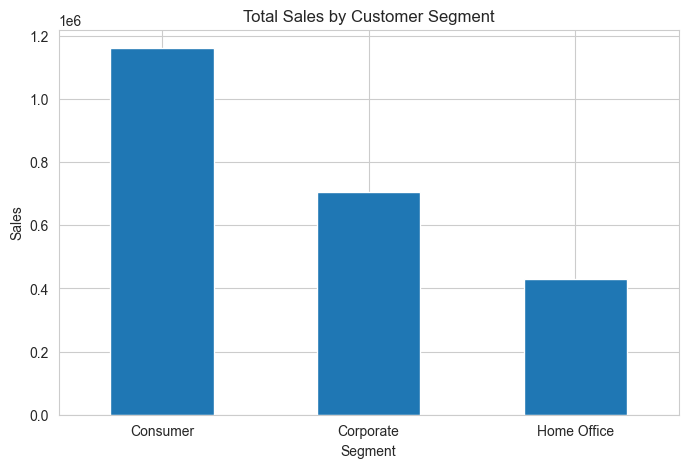

In [3]:
plt.figure(figsize=(8,5))

segment_sales.plot(kind="bar")

plt.title("Total Sales by Customer Segment")
plt.ylabel("Sales")

plt.xticks(rotation=0)
plt.show()

### Insight

The Consumer segment generates the highest total sales, significantly outperforming the Corporate and Home Office segments.

This indicates that individual consumers represent the largest customer base and the primary source of revenue for the business.

## Business Question 2

Which customer segments generate the most profit?

In [4]:
segment_profit = (
    df.groupby("Segment")["Profit"]
    .sum()
    .sort_values(ascending=False)
)

segment_profit

Segment
Consumer       134119.2092
Corporate       91979.1340
Home Office     60298.6785
Name: Profit, dtype: float64

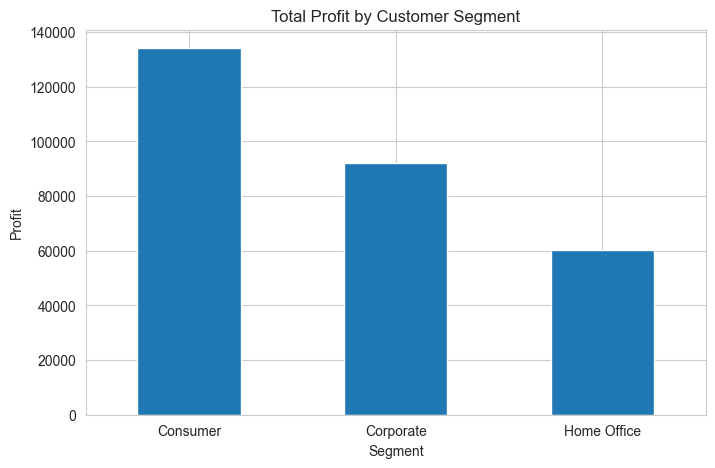

In [5]:
plt.figure(figsize=(8,5))

segment_profit.plot(kind="bar")

plt.title("Total Profit by Customer Segment")
plt.ylabel("Profit")

plt.xticks(rotation=0)
plt.show()

### Insight

The Consumer segment generates the highest total profit, followed by the Corporate segment and then Home Office.

This mirrors the sales distribution, indicating that individual consumers are both the largest revenue source and the most profitable customer segment for the business.

## Baseline Metric: Average Order Value

In [6]:
average_order_value = df.groupby("Order ID")["Sales"].sum().mean()

average_order_value

np.float64(458.61466566180883)

### Insight

The average order value is approximately $459.

This represents the average revenue generated per transaction in the dataset and serves as a baseline metric for understanding order size.

## Business Question 4

Which customer segment has the highest average order value?

In [7]:
order_segment_sales = (
    df.groupby(["Order ID", "Segment"])["Sales"]
    .sum()
    .reset_index()
)

order_segment_sales.head()

,Order ID,Segment,Sales
0,CA-2014-100006,Consumer,377.970
1,CA-2014-100090,Corporate,699.192
2,CA-2014-100293,Home Office,91.056
3,CA-2014-100328,Consumer,3.928
4,CA-2014-100363,Corporate,21.376


In [8]:
segment_aov = (
    order_segment_sales.groupby("Segment")["Sales"]
    .mean()
    .sort_values(ascending=False)
)

segment_aov

Segment
Home Office    472.665730
Corporate      466.411075
Consumer       449.111116
Name: Sales, dtype: float64

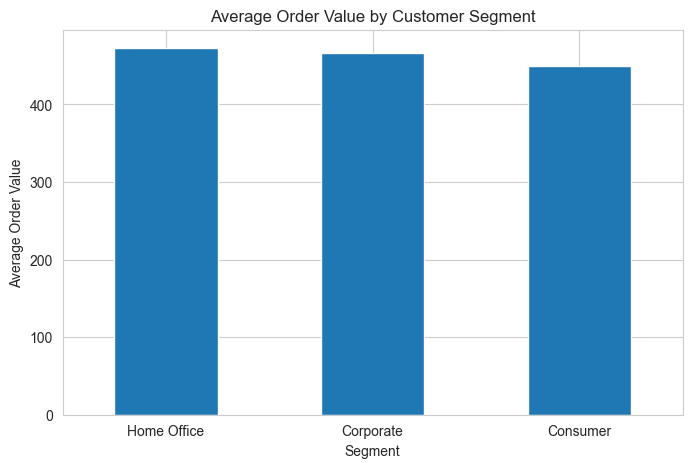

In [9]:
plt.figure(figsize=(8,5))

segment_aov.plot(kind="bar")

plt.title("Average Order Value by Customer Segment")
plt.ylabel("Average Order Value")

plt.xticks(rotation=0)
plt.show()

## Business Question 5

Which customers generate the most profit?

In [10]:
customer_profit = (
    df.groupby("Customer Name")["Profit"]
    .sum()
    .sort_values(ascending=False)
)

customer_profit.head(10)

Customer Name
Tamara Chand            8981.3239
Raymond Buch            6976.0959
Sanjit Chand            5757.4119
Hunter Lopez            5622.4292
Adrian Barton           5444.8055
Tom Ashbrook            4703.7883
Christopher Martinez    3899.8904
Keith Dawkins           3038.6254
Andy Reiter             2884.6208
Daniel Raglin           2869.0760
Name: Profit, dtype: float64

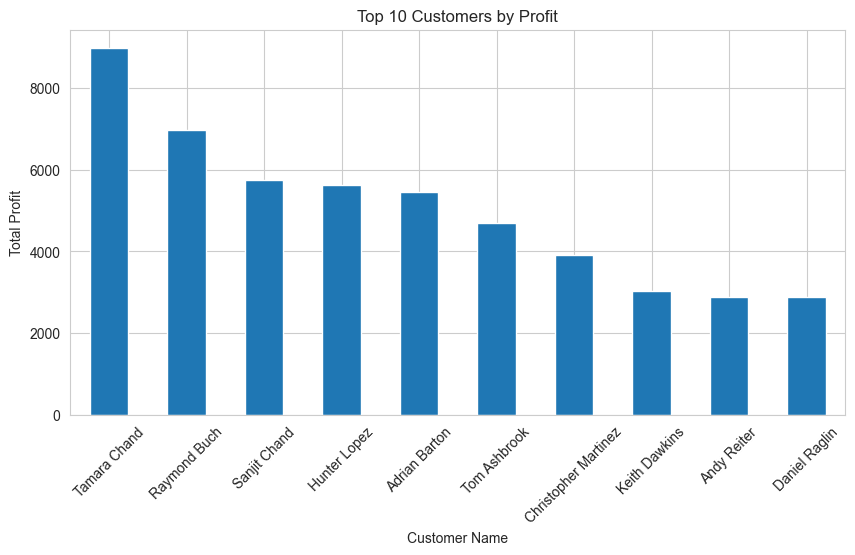

In [11]:
plt.figure(figsize=(10,5))

customer_profit.head(10).plot(kind="bar")

plt.title("Top 10 Customers by Profit")
plt.ylabel("Total Profit")

plt.xticks(rotation=45)
plt.show()

### Insight

Some customers generate substantially more profit than others.

Identifying and retaining these high-profit customers could help improve overall business profitability.

## Business Question 6

Which customer segment is the most profitable on average?

In [12]:
customer_segment_profit = (
    df.groupby(["Segment", "Customer Name"])["Profit"]
    .sum()
    .reset_index()
)

segment_avg_profit = (
    customer_segment_profit.groupby("Segment")["Profit"]
    .mean()
    .sort_values(ascending=False)
)

segment_avg_profit

Segment
Home Office    407.423503
Corporate      389.742093
Consumer       327.919827
Name: Profit, dtype: float64

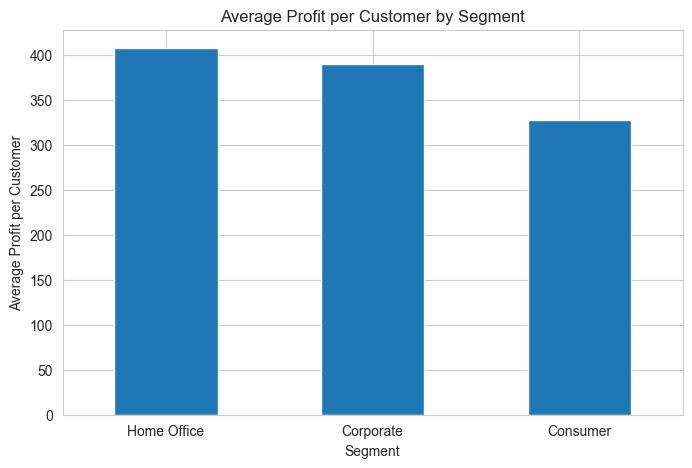

In [13]:
plt.figure(figsize=(8,5))

segment_avg_profit.plot(kind="bar")

plt.title("Average Profit per Customer by Segment")
plt.ylabel("Average Profit per Customer")

plt.xticks(rotation=0)
plt.show()

### Insight

Although the Consumer segment generates the highest total profit, customers in the Home Office segment produce the highest average profit per customer.

This suggests that Home Office clients tend to be more profitable on an individual basis, even if the overall revenue from this segment is smaller.